In [22]:
# %%
# CA 49 Roseland — Point 1 pipeline (Python)
# Requires: geopandas, pandas, shapely, requests, matplotlib, contextily (optional for basemaps)

import os
import io
import zipfile
import requests
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import urllib.parse
CENSUS_API_KEY = os.getenv("CENSUS_API_KEY")
import math

In [23]:
CA_PATH = "Community_Areas.zip"

ca = gpd.read_file(f"zip://{CA_PATH}")

# Project to  WGS84 
ca = ca.to_crs(4326)

print("Columns:", ca.columns.tolist())
print("Rows:", len(ca))
print(" Zip read successfully")

# Common name field is 'community' or 'communityA' depending on vintage; id is 'area_numbe'/'area_num_1'
if 'area_num_1' in ca.columns:
    ca['area_num'] = ca['area_num_1'].astype(int)
elif 'area_numbe' in ca.columns:
    ca['area_num'] = ca['area_numbe'].astype(int)
else:
    raise ValueError("Couldn't find area number field in CA shapefile")

roseland = ca.loc[ca['area_num'] == 49].copy()
assert len(roseland) == 1, "Roseland (CA 49) not found or duplicated"




Columns: ['area_numbe', 'community', 'area_num_1', 'shape_area', 'shape_len', 'geometry']
Rows: 77
 Zip read successfully


In [24]:
import requests, zipfile, io, geopandas as gpd, tempfile, os

def read_zipped_shapefile(url: str) -> gpd.GeoDataFrame:
    """
    Download a ZIP shapefile from a URL, save it temporarily,
    and load it as a GeoDataFrame.
    """
    print(f"  Downloading shapefile from {url} ...")
    r = requests.get(url)
    r.raise_for_status()

    # Create a temporary directory to store the zip
    with tempfile.TemporaryDirectory() as tmpdir:
        zip_path = os.path.join(tmpdir, "temp.zip")
        with open(zip_path, "wb") as f:
            f.write(r.content)

        # Read directly from the saved zip
        gdf = gpd.read_file(f"zip://{zip_path}")
        print(f" Loaded shapefile with {len(gdf)} rows and {len(gdf.columns)} columns.")
        return gdf



In [25]:
# ---------------------------
# 1) Get Cook County block groups TIGER/Line and intersect with Roseland
# ---------------------------
TIGER_BG_URL = "https://www2.census.gov/geo/tiger/TIGER2021/BG/tl_2021_17_bg.zip"

bg_il = read_zipped_shapefile(TIGER_BG_URL).to_crs(4326)
bg_il['COUNTYFP'] = bg_il['COUNTYFP'].astype(str)
bg_cook = bg_il[bg_il['COUNTYFP'] == '031'].copy()

bg_roseland = gpd.overlay(bg_cook, roseland[['geometry']], how='intersection')
bg_roseland['GEOID'] = bg_roseland['GEOID'].astype(str).str.zfill(12)
bg_ids = bg_roseland['GEOID'].unique().tolist()
print(f"Roseland BG count: {len(bg_ids)}")

 Loaded shapefile with 9898 rows and 13 columns.
Roseland BG count: 66


In [26]:
# ---------------------------
# 2) Load ACS data and filter for Roseland
# ---------------------------
df = pd.read_csv("Roseland-CA49/acs_blockgroups_all_years2010-2023.csv")
df['GEOID'] = df['GEOID'].astype(str).str.zfill(12)

df_latest = df[df['year'] == 2023].copy()
roseland_bg = df_latest[df_latest['GEOID'].isin(bg_ids)].copy()
print(f"Roseland block groups in data: {len(roseland_bg)}")

Roseland block groups in data: 66


In [27]:
# ---------------------------
# 3) Compute derived socioeconomic indicators
# ---------------------------
roseland_bg['unemp_rate'] = roseland_bg['B23025_005E'] / roseland_bg['B23025_003E']
roseland_bg['owner_share'] = roseland_bg['B25003_002E'] / roseland_bg['B25003_001E']
roseland_bg['vacancy_rate'] = roseland_bg['B25002_003E'] / roseland_bg['B25002_001E']
roseland_bg['pct_black'] = roseland_bg['B02001_003E'] / roseland_bg['B02001_001E']




In [28]:

# ---------------------------
# 4) Select features for scaling
# ---------------------------
features = [
    'B19013_001E',   # Median income
    'unemp_rate',
    'owner_share',
    'vacancy_rate',
    'pct_black',
    'B01002_001E'    # Median age
]

from sklearn.preprocessing import StandardScaler

X = roseland_bg[features].astype(float).fillna(0)
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=features,
    index=roseland_bg['GEOID']
)

print("Scaled matrix shape:", X_scaled.shape)
X_scaled.head()

Scaled matrix shape: (66, 6)


,B19013_001E,unemp_rate,owner_share,vacancy_rate,pct_black,B01002_001E
GEOID,,,,,,
170314912001,0.344395,1.573884,0.030015,1.376221,0.308801,-0.807858
170314912002,0.344498,-0.440355,0.902018,-1.363908,-0.032130,2.659638
170314912003,0.344488,-0.947958,0.540538,0.578958,0.456822,-0.356802
170314913002,0.344412,1.551568,0.004733,0.035024,-0.786101,-1.117959
170314913003,0.344453,-1.041238,-0.989687,1.117778,0.592989,-1.296502


In [29]:
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx

sim_matrix = cosine_similarity(X_scaled)
G = nx.Graph()

# Add nodes with attributes
for geoid, row in roseland_bg.iterrows():
    G.add_node(row['GEOID'], **row.to_dict())

# Add edges above a similarity threshold
threshold = 0.75  # adjust for density
for i in range(len(sim_matrix)):
    for j in range(i + 1, len(sim_matrix)):
        if sim_matrix[i, j] > threshold:
            G.add_edge(roseland_bg.iloc[i]['GEOID'],
                       roseland_bg.iloc[j]['GEOID'],
                       weight=sim_matrix[i, j])

print(f"Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")


Graph built: 66 nodes, 112 edges


In [30]:
import networkx as nx

# Basic metrics
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)
avg_clustering = nx.average_clustering(G)
components = nx.number_connected_components(G)

print(f"Nodes: {num_nodes}, Edges: {num_edges}")
print(f"Density: {density:.3f}, Avg Clustering: {avg_clustering:.3f}, Connected Components: {components}")


Nodes: 66, Edges: 112
Density: 0.052, Avg Clustering: 0.346, Connected Components: 9


In [31]:
from networkx.algorithms import community

communities = community.greedy_modularity_communities(G, weight='weight')

# Assign community labels to nodes
for i, c in enumerate(communities):
    for node in c:
        G.nodes[node]['community'] = i

print(f"Detected {len(communities)} socioeconomic clusters.")


Detected 13 socioeconomic clusters.


In [32]:
import pandas as pd

roseland_bg['community'] = roseland_bg['GEOID'].map(nx.get_node_attributes(G, 'community'))
summary = roseland_bg.groupby('community')[features].mean()
print(summary)

            B19013_001E  unemp_rate  owner_share  vacancy_rate  pct_black  \
community                                                                   
0          6.887333e+04    0.113676     0.777163      0.115080   0.964551   
1          3.930550e+04    0.097327     0.205182      0.254898   0.936332   
2          6.346288e+04    0.066962     0.727141      0.108185   0.987902   
3         -6.666667e+08    0.228122     0.717135      0.277800   0.865289   
4          5.083167e+04    0.370737     0.600839      0.164215   0.965974   
5          4.879717e+04    0.264160     0.582258      0.338347   0.921087   
6          5.912660e+04    0.151053     0.828767      0.065841   0.865640   
7          7.834300e+04    0.141950     0.674872      0.206116   0.840778   
8          5.838950e+04    0.151157     0.550655      0.175155   0.165298   
9          4.875000e+04    0.369942     0.598930      0.186957   0.783359   
10         3.797200e+04    0.513189     0.357664      0.130159   0.656566   

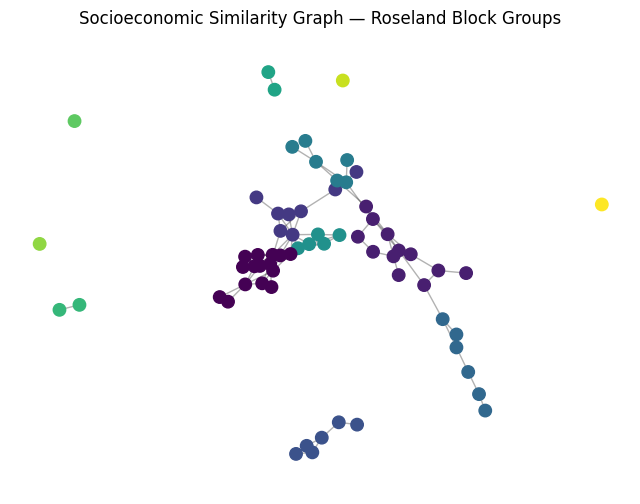

In [33]:
import matplotlib.pyplot as plt

# The graph (network) shows how block groups are connected based on cosine similarity across key socioeconomic variables
# (income, unemployment, vacancy, homeownership, age, race composition). Each node is a block group, and edges link highly similar ones.

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42, weight='weight')
colors = [G.nodes[n]['community'] for n in G.nodes]
nx.draw_networkx_nodes(G, pos, node_color=colors, cmap='viridis', node_size=80)
nx.draw_networkx_edges(G, pos, alpha=0.3)
plt.title("Socioeconomic Similarity Graph — Roseland Block Groups")
plt.axis('off')
plt.show()


In [34]:
components = list(nx.connected_components(G))
print(f"{len(components)} connected components")

# Largest component size
largest = max(components, key=len)
print(f"Largest component: {len(largest)} nodes")


9 connected components
Largest component: 28 nodes


In [35]:
import networkx as nx

components = list(nx.connected_components(G))
print(f"Number of connected components: {len(components)}")

# Assign component ID to each node
component_dict = {}
for i, comp in enumerate(components):
    for geoid in comp:
        component_dict[geoid] = i

roseland_bg['component'] = roseland_bg['GEOID'].map(component_dict)
print(roseland_bg['component'].value_counts().head())


Number of connected components: 9
component
1    28
0    24
4     6
8     2
5     2
Name: count, dtype: int64


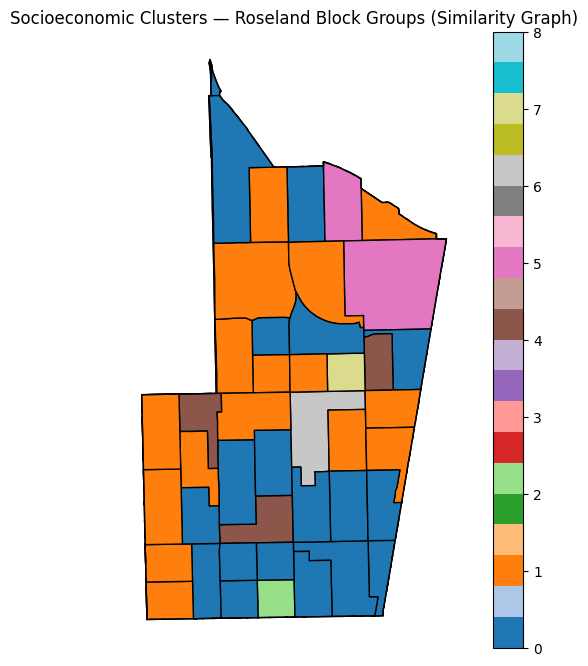

In [36]:
bg_roseland['GEOID'] = bg_roseland['GEOID'].astype(str)
roseland_map = bg_roseland.merge(
    roseland_bg[['GEOID', 'component']],
    on='GEOID',
    how='left'
)

# The map projects those similarity-based clusters spatially within Roseland, showing where socioeconomically similar areas are located.
# Distinct colors indicate separate clusters identified from the similarity network.

fig, ax = plt.subplots(figsize=(8, 8))
roseland_map.plot(column='component', cmap='tab20', legend=True, ax=ax, edgecolor='black')
roseland.boundary.plot(ax=ax, color='black', linewidth=1)
ax.set_title("Socioeconomic Clusters — Roseland Block Groups (Similarity Graph)")
ax.axis('off')
plt.show()


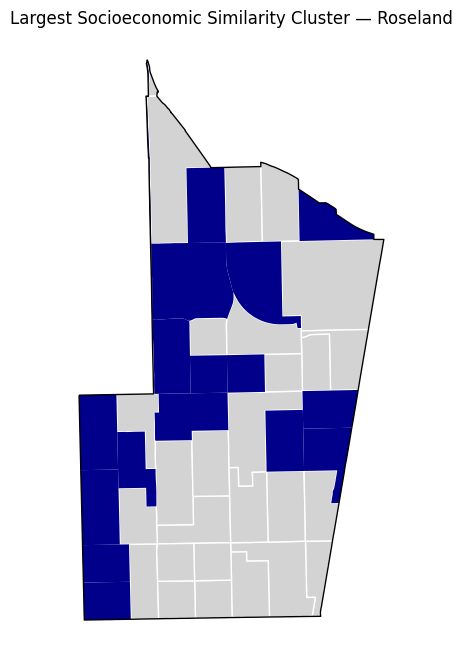

In [37]:
largest = max(components, key=len)
roseland_map['in_largest'] = roseland_map['GEOID'].isin(largest)

# The map isolates the largest connected cluster, representing Roseland’s socioeconomic “core” 
# the contiguous area of block groups that share the most similar economic and demographic conditions.

fig, ax = plt.subplots(figsize=(8, 8))
roseland_map.plot(ax=ax, color='lightgrey', edgecolor='white')
roseland_map[roseland_map['in_largest']].plot(ax=ax, color='darkblue')
roseland.boundary.plot(ax=ax, color='black', linewidth=1)
ax.set_title("Largest Socioeconomic Similarity Cluster — Roseland")
ax.axis('off')
plt.show()


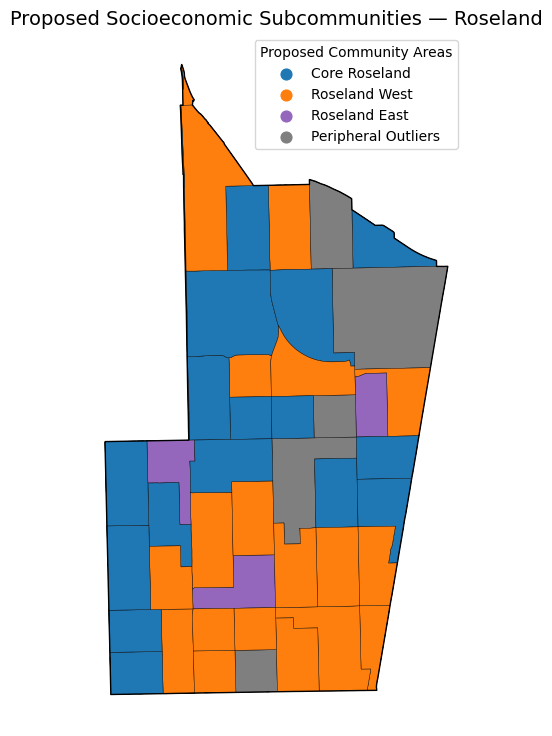

In [40]:
roseland_map['component'].unique()
component_to_area = {
    1: "Core Roseland",
    0: "Roseland West",
    4: "Roseland East"
}

# Default others to Peripheral
roseland_map['proposed_area'] = roseland_map['component'].map(component_to_area).fillna("Peripheral Outliers")
area_colors = {
    "Core Roseland": "#1f77b4",      # dark blue
    "Roseland West": "#ff7f0e",      # orange
    "Roseland East": "#9467bd",      # purple
    "Peripheral Outliers": "#7f7f7f" # gray
}

fig, ax = plt.subplots(figsize=(9, 9))
roseland_map.plot(
    ax=ax,
    color=roseland_map['proposed_area'].map(area_colors),
    edgecolor='black',
    linewidth=0.3
)
roseland.boundary.plot(ax=ax, color='black', linewidth=1)

for label, color in area_colors.items():
    ax.scatter([], [], c=color, label=label, s=60)
ax.legend(title="Proposed Community Areas", loc="upper right", frameon=True)
ax.set_title("Proposed Socioeconomic Subcommunities — Roseland", fontsize=14)
ax.axis('off')
plt.show()
